In [1]:
import pandas as pd 

df = pd.read_csv('отп_тестовое.xlsx - Данные (копия).csv')

In [ ]:
# знакомлюсь с данными для дальнейшего анализа

In [139]:
df.head(2)

,Q0. В какой роли вы обрабатываете обращения от юридических лиц?,Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?,Q1_1. Что нам нужно улучшить?,Q2. Насколько вам удобно и понятно сейчас выполнять поиск обращений в HCL Notes?,Q2_1. Что нам нужно улучшить?,Q3. Насколько вам удобно и понятно сейчас просматривать данные по обращению в HCL Notes?,Q3_1. Что нам нужно улучшить?,Q4. Насколько вам удобно и понятно обрабатывать обращение?,Q4_1. Что нам нужно улучшить?,"Q5. Насколько вам удобно и понятно работать с процессом сбора экспертизы от других сотрудников банка для рассмотрения обращений (HCL Notes, zulip, мессенджер)?",Q5_1. Что нам нужно улучшить?,Q6. Насколько вам удобен и понятен функционал предоставления ответа по обращению?,Q6_1. Что нам нужно улучшить?
0,Регистратор (регистрирует обращения),Затрудняюсь ответить,Не регистрировала обращения через лотус\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Регистратор (регистрирует обращения),3,"С заявками работаем редко, модно было бы сдела...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 13 columns):
 #   Column                                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                                           --------------  ----- 
 0   Q0. В какой роли вы обрабатываете обращения от юридических лиц?                                                                                                  97 non-null     object
 1   Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?                                                                                  13 non-null     object
 2   Q1_1. Что нам нужно улучшить?                                                                                                           

## Q0

In [ ]:
# Считаю кол-во уникальных значений по каждому вопросу

In [11]:
df.iloc[:, 0].value_counts().to_frame()

,count
Q0. В какой роли вы обрабатываете обращения от юридических лиц?,
Обработчик (рассматривает и предоставляет ответ по обращению),81
Регистратор (регистрирует обращения),11
"Контролер (работает со статистикой, работает с sla, переназначение обращение)",3
"Регистратор (регистрирует обращения), Обработчик (рассматривает и предоставляет ответ по обращению), Контролер (работает со статистикой, работает с sla, переназначение обращение)",1
"Регистратор (регистрирует обращения), Обработчик (рассматривает и предоставляет ответ по обращению)",1


#### Выводы:
1. Есть 3 основных роли (в редких случаях роли комбинируются):
- Обработчик (рассматривает и предоставляет ответ по обращению)	
- Регистратор (регистрирует обращения)	
- Контролер (работает со статистикой, работает с sla, переназначение обращение)
2. Каждый отдельный вопрос опросника предназначен не для всех пользователей, а для пользователей с определенной ролью (следовательно, при дальнейшем анализе данных имеет смысл применить фильтрацию)
3. На основе ролей можно построить схему упрощенную схему бизнес-процесса, который помогает реализовывать система


## Q1

In [59]:
df_q1 = df.iloc[:, 1].value_counts().to_frame().reset_index()
df_q1

,Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?,count
0,Затрудняюсь ответить,4
1,4,3
2,5,3
3,3,2
4,2,1


<Axes: xlabel='Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?'>

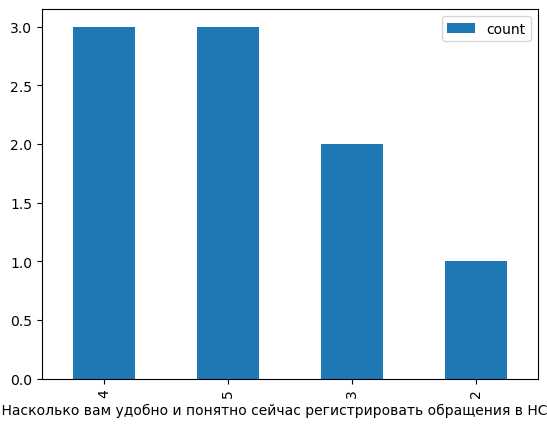

In [60]:
df.iloc[:, 1].value_counts().to_frame().iloc[1:,:].plot(kind='bar')

In [61]:
df_q1 = df_q1.iloc[1:,:].copy()

In [65]:
count_answers = df_q1['count'].sum()
avg_reg_satisfaction = df_q1['Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?'].astype(int) * df_q1['count']
avg_reg_satisfaction = avg_reg_satisfaction.sum() / count_answers

In [64]:
print(f'Средняя оценка удовлетворенности процессом регистрации обращения: {round(avg_reg_satisfaction, 2)}')

Средняя оценка удовлетворенности процессом регистрации обращения: 3.89


## Q1_1

In [15]:
df.iloc[:, 2].value_counts().to_frame()

,count
Q1_1. Что нам нужно улучшить?,
-,3
Не регистрировала обращения через лотус\n,1
"С заявками работаем редко, модно было бы сделать так, чтобы исполнители и наблюдатели подтягивались автоматически.",1
Регистрирую обращения через UFS,1
Затрудняюсь ответить,1
Усовершенствовать,1
тематики расширить,1
нужно видеть уже открытые обращения\nнужна возможность регистрировать обращения от юр лиц - не клиентов,1
Обращения регистрируем в ЕФС,1


## Q2

In [71]:
df.iloc[:, 3].value_counts().to_frame()

,count
Q2. Насколько вам удобно и понятно сейчас выполнять поиск обращений в HCL Notes?,
5,22
2,19
4,19
3,19
1,6
Затрудняюсь ответить,1


<Axes: xlabel='Q2. Насколько вам удобно и понятно сейчас выполнять поиск обращений в HCL Notes?'>

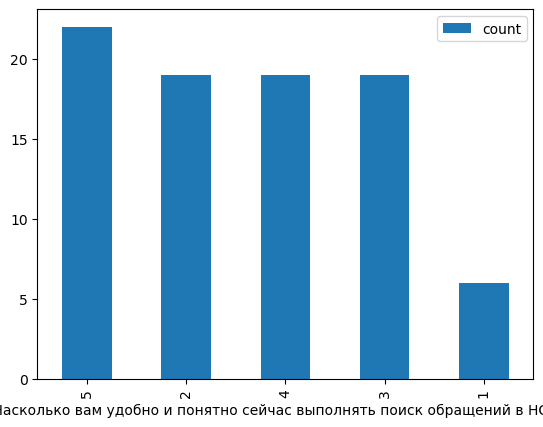

In [73]:
# Визуализация

df.iloc[:, 3].value_counts().to_frame().iloc[:-1,:].plot(kind='bar')

In [90]:
df_q2 = df.iloc[:, 3].value_counts().to_frame().iloc[:-1,:].reset_index().copy()

In [91]:
count_answers = df_q2['count'].sum()
avg_proc_satisfaction = df_q2['Q2. Насколько вам удобно и понятно сейчас выполнять поиск обращений в HCL Notes?'].astype(int) * df_q2['count']
avg_proc_satisfaction = avg_proc_satisfaction.sum() / count_answers

In [93]:
print(f'Средняя оценка удовлетворенности процессом рассмотрения обращения: {round(avg_proc_satisfaction, 2)}')

Средняя оценка удовлетворенности процессом рассмотрения обращения: 3.38


## Q2_1

In [74]:
# очень много уникальных значений, требуется фильтрация

df.iloc[:, 4].value_counts().to_frame().reset_index()

,Q2_1. Что нам нужно улучшить?,count
0,,5
1,все хорошо,3
2,все устраивает,2
3,-,2
4,.,2
...,...,...
72,Затрудняюсь ответить,1
73,В целом неудобный подход к приему обращений и ...,1
74,"Не удобно отследить цепочку сообщений, если с ...",1
75,Сделать поиск по наименованию клиента \nСделат...,1


Для упрощенной обработки качественных данных ответы на развернутые вопросы были отфильтрованы только для пользователей, которые поставили в предыдущем вопросе оценку 2 и 1. При наличие больших временных ресурсов имеет смысл обработать ответы пользователей с оценками 3.

In [78]:
df_q2_1 = df.loc[df['Q2. Насколько вам удобно и понятно сейчас выполнять поиск обращений в HCL Notes?'].
                 isin(['1', '2'])]

In [128]:
df_q2_1 = df_q2_1.iloc[:, 4].to_frame().copy()

In [130]:
df_q2_1.to_excel('рассмотрение.xlsx', index=False)

## Q3

In [18]:
df.iloc[:, 5].value_counts().to_frame()

,count
Q3. Насколько вам удобно и понятно сейчас просматривать данные по обращению в HCL Notes?,
5,27
3,19
4,16
2,14
1,5
Затрудняюсь ответить,5


<Axes: xlabel='Q3. Насколько вам удобно и понятно сейчас просматривать данные по обращению в HCL Notes?'>

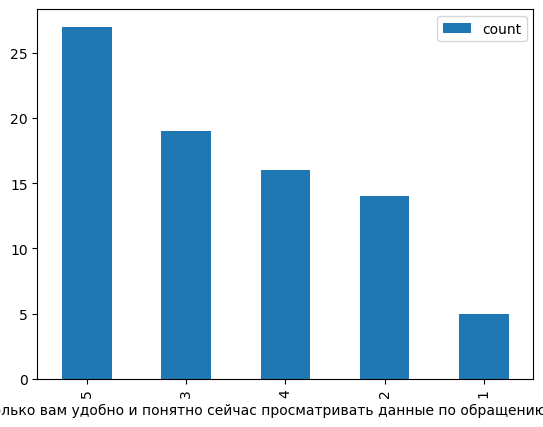

In [95]:
df.iloc[:, 5].value_counts().to_frame().iloc[:-1,:].plot(kind='bar')

In [96]:
df_q3 = df.iloc[:, 5].value_counts().to_frame().iloc[:-1,:].reset_index().copy()
count_answers = df_q3['count'].sum()
avg_view_satisfaction = df_q3['Q3. Насколько вам удобно и понятно сейчас просматривать данные по обращению в HCL Notes?'].astype(int) * df_q3['count']
avg_view_satisfaction = avg_view_satisfaction.sum() / count_answers
print(f'Средняя оценка удовлетворенности процессом просмотра данных обращения: {round(avg_view_satisfaction, 2)}')

Средняя оценка удовлетворенности процессом просмотра данных обращения: 3.57


## Q3_1

In [19]:
df.iloc[:, 6].value_counts().to_frame()

,count
Q3_1. Что нам нужно улучшить?,
,7
-,6
.,4
все устраивает,2
+,2
...,...
1,1
все отлично,1
Все понятно,1


In [135]:
df_q3_1 = df.loc[df['Q3. Насколько вам удобно и понятно сейчас просматривать данные по обращению в HCL Notes?'].
                 isin(['1', '2'])]
df_q3_1 = df_q3_1.iloc[:, 6].to_frame().copy()
df_q3_1.to_excel('просмотр_данных.xlsx', index=False)

## Q4

In [20]:
df.iloc[:, 7].value_counts().to_frame()

,count
Q4. Насколько вам удобно и понятно обрабатывать обращение?,
5,27
4,23
3,15
2,12
1,4
Затрудняюсь ответить,2


In [123]:
df_q4 = df.iloc[:, 7].value_counts().to_frame().iloc[:-1,:].reset_index().copy()
count_answers = df_q4['count'].sum()
avg_treat_satisfaction = df_q4['Q4. Насколько вам удобно и понятно обрабатывать обращение?'].astype(int) * df_q4['count']
avg_treat_satisfaction = avg_treat_satisfaction.sum() / count_answers
print(f'Средняя оценка удовлетворенности процессом обработки обращения: {round(avg_treat_satisfaction, 2)}')

Средняя оценка удовлетворенности процессом обработки обращения: 3.7


## Q4_1

In [22]:
df.iloc[:, 8].value_counts().to_frame().head()

,count
Q4_1. Что нам нужно улучшить?,
-,10
,7
.,5
+,3
все понятно,2


## Q5

In [109]:
df_q5 = df.iloc[:, 9].value_counts().to_frame().reset_index()
df_q5

,"Q5. Насколько вам удобно и понятно работать с процессом сбора экспертизы от других сотрудников банка для рассмотрения обращений (HCL Notes, zulip, мессенджер)?",count
0,5,26
1,Затрудняюсь ответить,22
2,4,19
3,3,11
4,2,4
5,1,1


In [110]:
df_q5 = df_q5[df_q5['Q5. Насколько вам удобно и понятно работать с процессом сбора экспертизы от других сотрудников банка для рассмотрения обращений (HCL Notes, zulip, мессенджер)?'] != 'Затрудняюсь ответить']

In [111]:
df_q5

,"Q5. Насколько вам удобно и понятно работать с процессом сбора экспертизы от других сотрудников банка для рассмотрения обращений (HCL Notes, zulip, мессенджер)?",count
0,5,26
2,4,19
3,3,11
4,2,4
5,1,1


In [118]:
count_answers = df_q5['count'].sum()
avg_exp_satisfaction = df_q5['Q5. Насколько вам удобно и понятно работать с процессом сбора экспертизы от других сотрудников банка для рассмотрения обращений (HCL Notes, zulip, мессенджер)?'].astype(int) * df_q5['count']
avg_exp_satisfaction = avg_exp_satisfaction.sum() / count_answers
print(f'Средняя оценка удовлетворенности процессом сбора экспертизы: {round(avg_exp_satisfaction, 2)}')






Средняя оценка удовлетворенности процессом сбора экспертизы: 4.07


## Q5_1

In [25]:
df.iloc[:, 10].value_counts().to_frame().head()

,count
Q5_1. Что нам нужно улучшить?,
-,16
,9
.,4
+,3
Удобно,2


## Q6

In [26]:
df.iloc[:, 11].value_counts().to_frame()

,count
Q6. Насколько вам удобен и понятен функционал предоставления ответа по обращению?,
5,33
4,19
3,14
1,7
2,7
Затрудняюсь ответить,3


In [126]:
df_q6 = df.iloc[:, 11].value_counts().to_frame().iloc[:-1,:].reset_index().copy()
count_answers = df_q6['count'].sum()
avg_ans_satisfaction = df_q6['Q6. Насколько вам удобен и понятен функционал предоставления ответа по обращению?'].astype(int) * df_q4['count']
avg_ans_satisfaction = avg_ans_satisfaction.sum() / count_answers
print(f'Средняя оценка удовлетворенности процессом ответа на обращение: {round(avg_ans_satisfaction, 2)}')

Средняя оценка удовлетворенности процессом ответа на обращение: 3.65


## Q6_1

In [137]:
df.iloc[:, 12].value_counts().to_frame().head()

,count
Q6_1. Что нам нужно улучшить?,
-,13
,8
.,7
понятен,3
+,2


In [138]:
df_q6_1 = df.loc[df['Q6. Насколько вам удобен и понятен функционал предоставления ответа по обращению?'].
                 isin(['1', '2'])]
df_q6_1 = df_q6_1.iloc[:, 12].to_frame().copy()
df_q6_1.to_excel('ответ.xlsx', index=False)

# 1 задача: Оценка удовлетворенности пользователей

Оценка удовлетворенности каждого сегмента пользователей (сегментирование по ролям и выполняемым задачам) расчитывалась как среднее арифмитическое баллов по каждой субшкале опросника.

Общая удовлетворенность всех пользователей общим функционалом системы расчитывалась как тотал по всем субщкалам опросника.

In [127]:
print(f'Удовлетворенность процессом регистрации: {round(avg_reg_satisfaction, 2)}')
print(f'Удовлетворенность процессом рассмотрения: {round(avg_proc_satisfaction, 2)}')
print(f'Удовлетворенность процессом просмотра данных обращения: {round(avg_view_satisfaction, 2)}')
print(f'Удовлетворенность процессом обработки обращения: {round(avg_treat_satisfaction, 2)}')
print(f'Удовлетворенность процессом сбора экспертизы: {round(avg_exp_satisfaction, 2)}')
print(f'Удовлетворенность процессом ответа на обращение: {round(avg_ans_satisfaction, 2)}')

total = avg_reg_satisfaction + avg_proc_satisfaction + avg_view_satisfaction + avg_treat_satisfaction + avg_exp_satisfaction + avg_ans_satisfaction
total = total / 6

print(f'Общая удовлетворенность сервисом: {round(total, 2)}')

Удовлетворенность процессом регистрации: 3.89
Удовлетворенность процессом рассмотрения: 3.38
Удовлетворенность процессом просмотра данных обращения: 3.57
Удовлетворенность процессом обработки обращения: 3.7
Удовлетворенность процессом сбора экспертизы: 4.07
Удовлетворенность процессом ответа на обращение: 3.65
Общая удовлетворенность сервисом: 3.71


# 2 задача: Определить ТОП 3 болей пользователей, пояснить как выбирали

Опираясь на среднюю оценку удовлетворенности пользователя, было принято решение сосредоточиться на анализе болей пользователей по трем самым неудовлетворительным направлениям: 
- процесс рассмотрения обращения
- процесс  просмотра данных обращения
- процесс ответа на обращение 

Я решила сосредоточиться на отзывах пользователей, которые поставили самые низкие оценки (1 и 2) в вопросах 2, 3 и 6. Выделив данные комментарии, я сохранила их в отдельные файлы. Прочитала и составила саммари главных болей пользователей (частично использовала llm для сбора статистики по текстовым данным). 

**Топ 3 боли пользователей:**
1. Главная боль в процессе рассмотрения обращения: Отсутствие идентификации клиента в теме письма (нет наименования, ИНН, кода подразделения) — приходится открывать каждое письмо, чтобы понять, от кого оно и к кому относится.
2. Главная боль в процессе просмотра данных обращения: Нет категоризации и классификации обращений — все типы писем (запросы, документы, платежи, переоформление) находятся вместе, невозможно понять, с чем именно пришло обращение без открытия.
3. Главная боль в процессе ответа на обращение: При ответе клиента теряется связь с исходным запросом (нет сохранения ленты/истории переписки, не видно, на какой конкретно запрос отвечает клиент), а сам процесс формирования ответа клиенту является ручной работой (нужно вручную копировать адреса, вставлять ИНН/КПП в тему, искать исходный запрос).

**Дополнительные пояснения по поводу выбора болей (почему 3, а не больше):**

1. При большем временом ресурсе имеет смысл более детально погрузиться в данные, особенно в качественные. Однако в условиях ограниченного времени разумно сосредоточиться на приоритетных и самых западающих направлениях, которые вызывают наиболшее недовольство у пользователей.
2. Ресурсы разработчиков не бесконечны, поэтому для итерационного улучшения продукта также имеет смысл сосредоточиться на 3 приоритетных направлениях улучшения продукта, а с менее приорететными работать по мере развития продукта, улучшая его 
3. Среди пользователей доминирующая группа - Обработчики (~81), поэтому задачи, которые они решают, кажутся мне наиболее приорететными, относительно проблем, с которыми сталкиваются пользователи с менее популярными ролями. Их проблемы имеет смысл решать при последующей доработке продукта
4. Просмотр данных - задача, актуальная для двух типов ролей, поэтому она такж екажется мне приоритетной

# 3 задача: Определить ТОП 3 новых требований пользователей, которые надо учесть при разработке новой системы, пояснить как их выбирали

При выборе требований для учета при разработке новой системы я опиралась на главные боли пользователя, подбирая решение так, чтобы боль была решена и продукт создавал ценность для пользователя.

**Топ 3 требования для разработки:**
1. Для работы с проблемами при рассмотрении обращения: В списке обращений должны быть видимыми без открытия письма поля: «Наименование клиента», «ИНН», «Код подразделения (ДО)». Также должен работать поиск и фильтрация по этим полям.
2. Для работы с проблемами при просмотре данных обращения: Внедрение обязательной категоризации обращений на входе (например: «Запрос документов», «Платеж», «Переоформление», «Консультация») с возможностью фильтрации и сортировки по типам. К каждому обращению автоматически привязывать код подразделения клиента для маршрутизации.
3. Для работы с проблемами при ответе на обращение: Автоматическое сохранение полной истории переписки (сквозная ветка/лента по каждому обращению), чтобы ответ клиента был явно привязан к исходному запросу. Кнопка «Ответить» должна автоматически подставлять корректные реквизиты клиента (адрес, ИНН/КПП в нужном формате) и не требовать ручного копирования.

# 4 задача: Наблюдения по ходу аналитики результатов, которые будет полезно учесть при разработке новой системы и при проведении подобных опросов в будущем.

**При проведении подобных опросов в будущем:**
1. В формулировке вопросов, оцениваемых по шкале Лайкерта (1-5) задавать четкий формат ответа или предоставлять возможность выбора одного варианта из представленных, чтобы в будущем:
- облегчить анализ данных опросного исследования
- убедиться, что все респонденты наделяют оценку одинаковым значением (поясняю: из многочисленных психометрических исследований известно, что особенность порядковых шкал в том, что люди по-разному вопринимают промежутки, четкие формулировки снижают это субъективное различие)
2. Сделать все вопросы обязательными для ответов, чтобы собрать более полную статистику. Как вариант: избавить от варианта "затрудняюсь ответить". психометрические исследования также говорят, что подобные варианты ответов - удобная возможность избежать ответ на вопрос тогда, когда респондент мог принести ценный инсайт своим ответом или увеличить выборку опросного исследования
3. Вопрос: "Что нам нужно улучшить?" сам по себе не очень коректен, так как у большинства людей вызывает чувство социальной желательности (что соответствует статистике по ответам на большинство вопросов подобного толка в текущем опроснике). Возможно, имеет смысл добавить вопросы, которые ориентируются на прошлый опыт пользователя, чтобы он более полно раскрыл, в чем состоит текущая проблема и как он хотел бы ее решить с помощью сервиса. Например: 
- Было: "Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?", "Q1_1. Что нам нужно улучшить?"
- Стало: "Q1. Насколько вам удобно и понятно сейчас регистрировать обращения в HCL Notes?", "Q1_1. Опишите ситуации из вашего прошлого опыта регистрации обращения в HCL Notes, когда вы сталкивались с проблемами"

Отмечу, что подобные формулировки скорее характерны для интервью, поэтому, возможно, имеет смысл провести качественное исследование или фокус группу для работы с улучшениями.

4. Сделать определенные вопросы опросника доступными только людям с определенной ролью, чтобы пользователи с неподходящей ролью и набором обязанностей не портили данные, отвечая на вопросы, которые на них не расчитаны (при фильтрации несколько раз было замечено подобное поведение) 


**Будет полезно учесть при разработке:**
- Разработать функционал, по максимум убирающий ручной труд
- Разработать четкую систему фильтрации
- Разработать более грамотную систему поиска